In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("AnimeList.csv")
print("loaded")

loaded


In [2]:
df[["source", "title"]].head(10)

,source,title
0,Manga,Inu x Boku SS
1,Manga,Seto no Hanayome
2,Manga,Shugo Chara!! Doki
3,Original,Princess Tutu
4,Manga,Bakuman. 3rd Season
5,Manga,Yume-iro Pâtissière
6,Manga,Ultra Maniac
7,Light novel,Shakugan no Shana II (Second)
8,Manga,Nodame Cantabile: Paris-hen
9,Manga,Ouran Koukou Host Club


In [3]:
df["source"].value_counts().head(15)

source
Unknown          4210
Original         3368
Manga            3120
Visual novel      888
Game              607
Light novel       563
Other             408
Novel             359
Music             314
4-koma manga      224
Web manga         150
Picture book       96
Book               93
Card game          59
Digital manga      10
Name: count, dtype: int64

In [4]:
df.groupby("source")["score"].mean()

source
4-koma manga     6.494286
Book             6.290968
Card game        6.052542
Digital manga    4.639000
Game             6.040165
Light novel      6.800391
Manga            6.763080
Music            5.200510
Novel            6.423621
Original         5.735413
Other            5.552549
Picture book     5.473750
Radio            5.488889
Unknown          5.977637
Visual novel     6.450822
Web manga        6.009067
Name: score, dtype: float64

In [26]:
source_df = df[["source", "score"]].copy()


source_stats = source_df.groupby("source").agg(
    avg_score = ("score", "mean"),
    anime_count = ("score", "count")
)
    
source_stats[
    source_stats["anime_count"] >= 100
].sort_values("anime_count", ascending=False).head(10)

,avg_score,anime_count
source,,
Unknown,5.977637,4210
Original,5.735413,3368
Manga,6.763080,3120
Visual novel,6.450822,888
Game,6.040165,607
Light novel,6.800391,563
Other,5.552549,408
Novel,6.423621,359
Music,5.200510,314


In [27]:
df[df["source"] == "Original"]\
    .sort_values("score", ascending=False)[
        ["title", "score"]
    ].head(10)

,title,score
14317,Kuunyan no Koutsuu Anzen: Tadashii Jitensha no...,10.00
14407,Ittekimasu,10.00
548,Manichi ga Tsurai Kimochi Wakarimasu ka: Yurus...,10.00
14454,Tat-chan - Momo-chan no Fushigina Taiken,9.50
14208,Hashire John,9.50
1028,Kimi no Na wa.,9.19
7403,Code Geass: Hangyaku no Lelouch R2,8.95
7105,Sen to Chihiro no Kamikakushi,8.92
9132,Cowboy Bebop,8.81
2068,Mononoke Hime,8.80


In [28]:
df[df["source"] == "Manga"]\
    .sort_values("score", ascending=False)[
        ["title", "score"]
    ].head(10)

,title,score
2555,Fullmetal Alchemist: Brotherhood,9.25
1252,Gintama°,9.15
8992,Gintama&#039;,9.11
418,Hunter x Hunter (2011),9.11
1307,3-gatsu no Lion 2nd Season,9.10
5783,Gintama&#039;: Enchousen,9.07
13230,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,9.04
6572,Koe no Katachi,9.04
10879,Gintama.,9.02
6553,Gintama,9.01


In [29]:
df[df["source"] == "Original"]["score"].describe()

count    3368.000000
mean        5.735413
std         1.628846
min         0.000000
25%         4.890000
50%         5.970000
75%         6.890000
max        10.000000
Name: score, dtype: float64

In [30]:
df[df["source"] == "Original"]["score"].value_counts().head(20)

score
0.00    95
5.00    31
4.00    30
6.00    24
4.50    22
5.50    21
6.25    19
5.78    18
6.50    17
5.33    17
7.40    16
5.67    16
6.40    16
6.63    16
6.33    16
6.94    16
7.50    15
5.70    15
6.88    15
5.64    15
Name: count, dtype: int64

<Axes: >

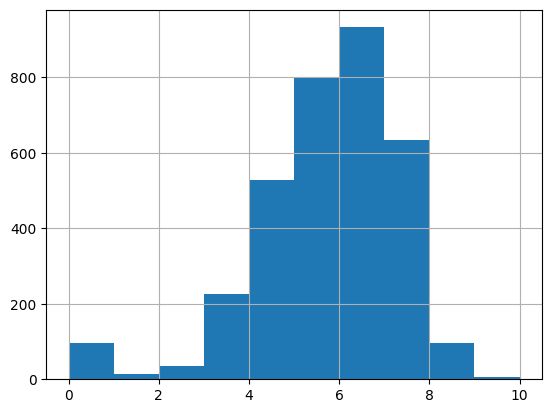

In [31]:
df[df["source"] == "Original"]["score"].hist()

In [32]:
df[
    (df["source"] == "Original")
    & (df["score"] == 0)
][["title", "score", "members", "scored_by"]]

,title,score,members,scored_by
145,Carol & Tuesday,0.0,1180,0
334,Shoujo☆Kageki Revue Starlight,0.0,2094,0
458,W&#039;z,0.0,513,0
639,K: Seven Stories Movie 1 - R:B - Blaze,0.0,40490,0
943,Kimitachi wa Dou Ikiru ka,0.0,455,0
...,...,...,...,...
14417,Uchuu no Hou: Reimei-hen,0.0,123,0
14418,Kurayami wa Kiken ga Ippai,0.0,31,0
14425,Wo Shi Jiang Xiaobai (2018),0.0,384,0
14442,Chara to Otamajakushi Shima,0.0,21,0


In [36]:
df.groupby("source")["score"].median()

source
4-koma manga     6.785
Book             6.400
Card game        6.670
Digital manga    4.870
Game             6.470
Light novel      7.230
Manga            7.010
Music            5.170
Novel            6.750
Original         5.970
Other            5.750
Picture book     5.700
Radio            5.530
Unknown          6.060
Visual novel     6.540
Web manga        6.570
Name: score, dtype: float64

In [37]:
df_clean = df[df["score"] > 0]
df_clean.groupby("source")["score"].mean()

source
4-koma manga     6.797757
Book             6.290968
Card game        6.612963
Digital manga    5.798750
Game             6.409755
Light novel      7.210207
Manga            6.975474
Music            5.250675
Novel            6.842967
Original         5.901885
Other            5.749848
Picture book     5.650323
Radio            5.488889
Unknown          5.996152
Visual novel     6.531733
Web manga        6.627647
Name: score, dtype: float64

<Axes: xlabel='source'>

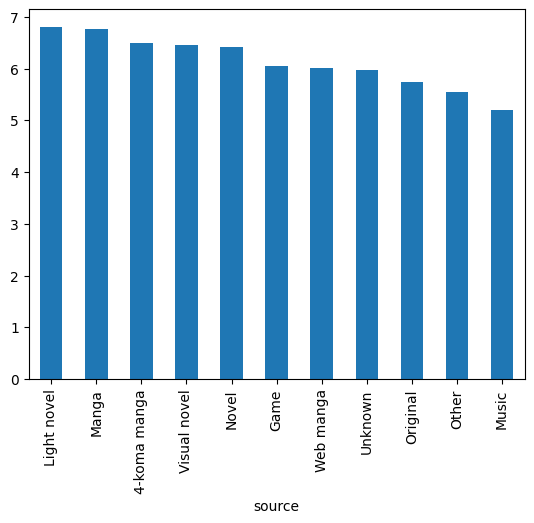

In [38]:
source_stats[
    source_stats["anime_count"] >= 100
].sort_values(
    "avg_score",
    ascending=False
)["avg_score"].plot.bar()